## Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 3. Поиск аномалий во временных рядах.**


#### **3.1 Поиск диссонансов с помощью алгоритма HotSAX**

# Артемьев М.О. ЕТ-228

##### 3.1.1 Загрузка и подготовка данных

В данной будет использоваться временной ряд, состоящий из показаний акселерометра.
Анализируемый временной ряд, описывает две активности человека - бег и шаг.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

practice_dir_path = '/content/drive/MyDrive/03 Discords'

os.chdir(practice_dir_path)

if practice_dir_path not in sys.path:
    sys.path.insert(0, practice_dir_path)

print("Рабочая папка:", os.getcwd())
print("Файлы:", os.listdir())

Mounted at /content/drive
Рабочая папка: /content/drive/MyDrive/03 Discords
Файлы: ['datasets', 'modules', 'pics', '03 Discords.ipynb']


In [2]:
!pip install scipy
!pip install scikit-learn

In [3]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from time import time
import pandas as pd

In [4]:
#fixme: Путь
dataset_dir_path = Path('datasets')
data_path = dataset_dir_path/'walk_run.txt'
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

В середине временного ряда происходит смена активности (бег заменяет шаг). Нетипичным поведением, которое мы могли бы назвать диссонансами в данном ряде выступает небольшой участок между активностями, когда человек плавно увеличивает скорость шага до бега. В ходе данной работе наша задача выделить с помощью различных алгоритмов границы нашего диссонанса.

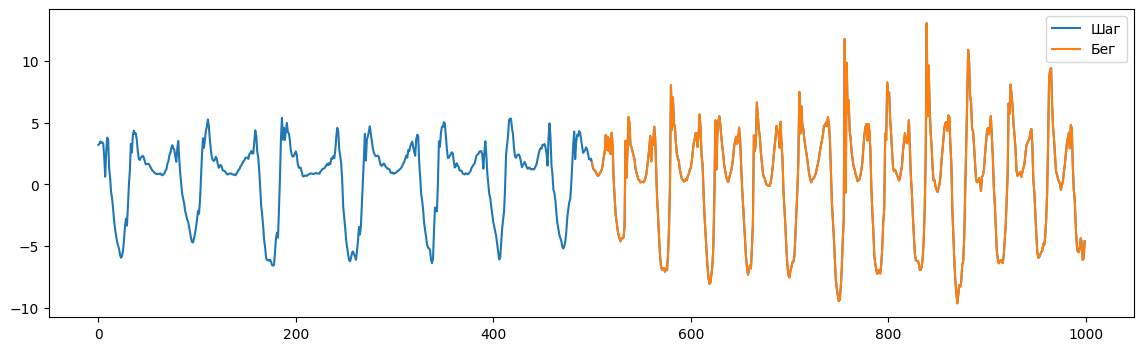

In [5]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

In [6]:
result={}
times={}

##### 3.1.2 Реализация полного перебора

Приводится пример кода для нахождения топ 5 диссонансов с помощью реализации полного беребора.
Вам необходимо добавить код для сбора времени обработки данных.

In [7]:
from modules.saxpy.discord import find_discords_brute_force
start = time()
discords_brute_force= np.stack(find_discords_brute_force(data[:], 50, 5))
end = time()

# Время выполнения в секундах
times['Brute Force'] = end - start

# Результаты поиска
result['Brute Force'] = discords_brute_force

print("Найденные диссонансы:")
print(discords_brute_force)

print(f"Время полного перебора: {times['Brute Force']:.3f} секунд")

Найденные диссонансы:
[[477.           5.88100934]
 [412.           5.32704317]
 [195.           3.39426635]
 [577.           3.35554403]
 [278.           3.10959389]]
Время полного перебора: 154.381 секунд


##### 3.1.3 HotSAX

Используя [реализацию](https://github.com/seninp/saxpy/blob/master/saxpy/hotsax.py) найдите топ 5 диссонансов ряда.
Произведите замер времени работы.

In [8]:
from modules.saxpy.hotsax import find_discords_hotsax

start = time()

discords_hotsax = np.stack(
    find_discords_hotsax(
        data,
        win_size=50,
        num_discords=5
    )
)

end = time()

# Сохраняем результаты и время работы
result['HotSAX'] = discords_hotsax
times['HotSAX'] = end - start

print("Найденные диссонансы HotSAX:")
print(discords_hotsax)

print(f"\nВремя HotSAX: {times['HotSAX']:.3f} секунд")
print(f"Время полного перебора: {times['Brute Force']:.3f} секунд")

Найденные диссонансы HotSAX:
[[477.           5.88100934]
 [412.           5.32704317]
 [195.           3.39426635]
 [577.           3.35554403]
 [278.           3.10959389]]

Время HotSAX: 2.901 секунд
Время полного перебора: 154.381 секунд


##### 3.1.4 Визаулизация

Вам необходимо реализовать код позволяющий:
1. Вывести на одном графике ряд и его диссонансы
2. Столбчатую диаграмму времени работы обоих алгоритмов
   
Постройте графики для обоих алгоритмов и сравните полученные результаты.

Пример графика:

![first_graf](pics/fig_ex_1.png)

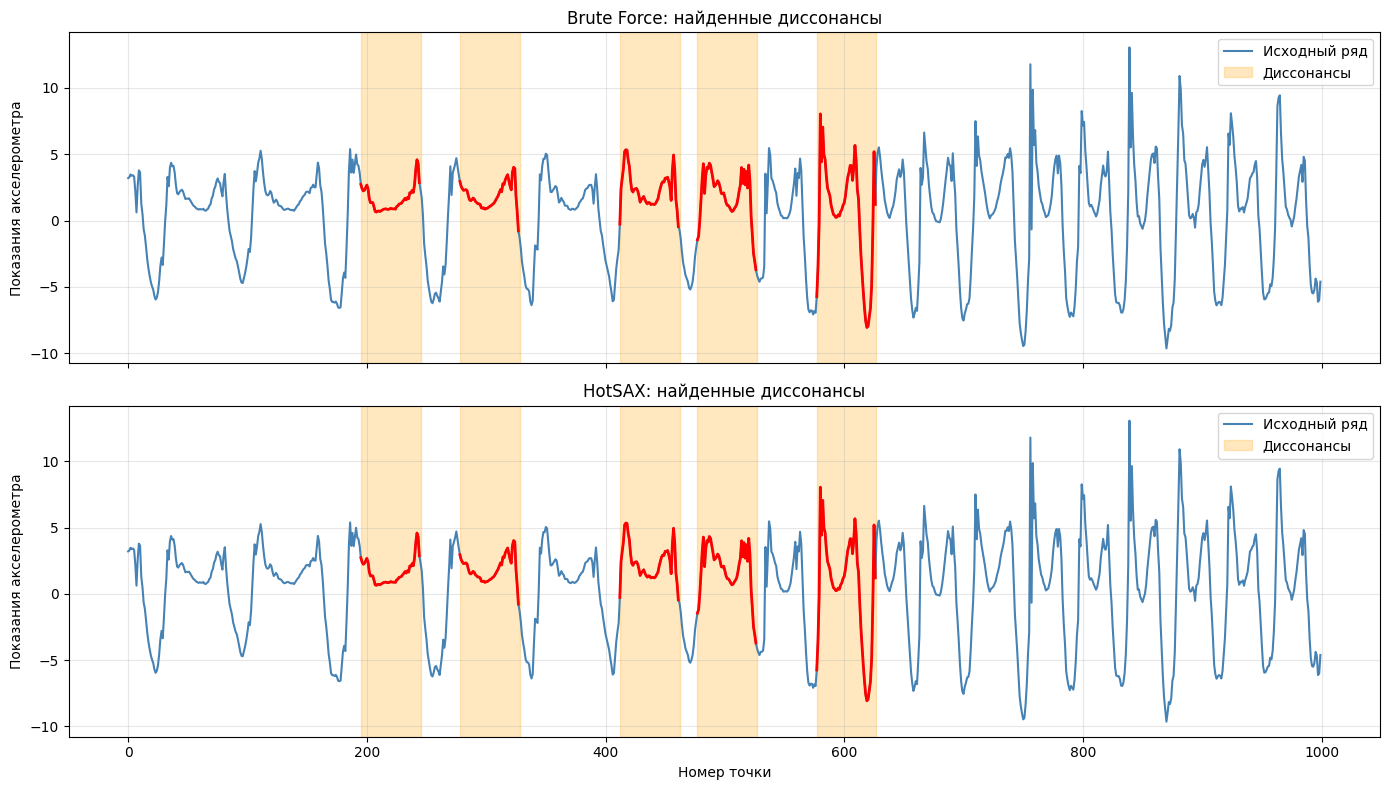

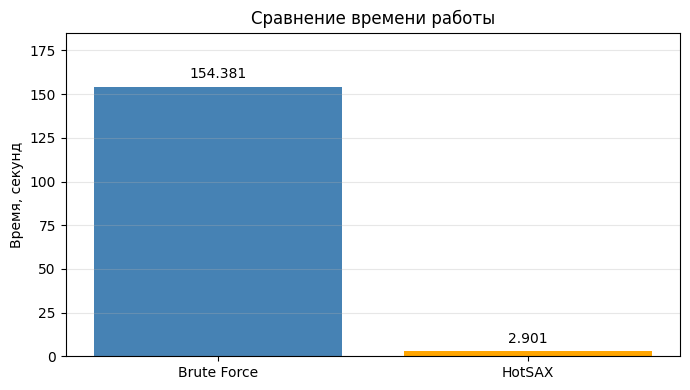

Индексы Brute Force: [477 412 195 577 278]
Индексы HotSAX: [477 412 195 577 278]
Индексы и расстояния совпадают: True
Отношение времени Brute Force к HotSAX: 53.21


In [9]:

algorithms = ['Brute Force', 'HotSAX']

# Ряд и найденные диссонансы для каждого алгоритма
fig, axes = plt.subplots(
    2, 1, figsize=(14, 8), sharex=True, sharey=True
)

for ax, name in zip(axes, algorithms):
    ax.plot(data, color='steelblue', label='Исходный ряд')

    for number, (idx, distance) in enumerate(result[name]):
        idx = int(idx)
        stop = idx + size_sub

        ax.axvspan(
            idx, stop,
            color='orange',
            alpha=0.25,
            label='Диссонансы' if number == 0 else None
        )

        ax.plot(
            np.arange(idx, stop),
            data[idx:stop],
            color='red',
            linewidth=2
        )

    ax.set_title(f'{name}: найденные диссонансы')
    ax.set_ylabel('Показания акселерометра')
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Номер точки')
plt.tight_layout()
plt.show()

# Столбчатая диаграмма времени работы
fig, ax = plt.subplots(figsize=(7, 4))

values = [times[name] for name in algorithms]
bars = ax.bar(
    algorithms, values,
    color=['steelblue', 'orange']
)

ax.bar_label(bars, fmt='%.3f', padding=4)
ax.set_ylabel('Время, секунд')
ax.set_title('Сравнение времени работы')
ax.set_ylim(0, max(values) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Сравнение результатов независимо от порядка строк
bf = result['Brute Force']
hs = result['HotSAX']

bf_sorted = bf[np.argsort(bf[:, 0])]
hs_sorted = hs[np.argsort(hs[:, 0])]

same = (
    bf_sorted.shape == hs_sorted.shape
    and np.allclose(bf_sorted, hs_sorted)
)

print("Индексы Brute Force:", bf[:, 0].astype(int))
print("Индексы HotSAX:", hs[:, 0].astype(int))
print("Индексы и расстояния совпадают:", same)

speedup = times['Brute Force'] / times['HotSAX']
print(f"Отношение времени Brute Force к HotSAX: {speedup:.2f}")

In [10]:
from matplotlib.patches import Rectangle

##### 3.1.5 Такси NY

Произведите поиск диссонансов с помощью обоих алгоритмов на наборе данных, содержащим информацию о среднем числе пассажиров в NY. Отобразите найденные диссонансы обоими алгоритмами.

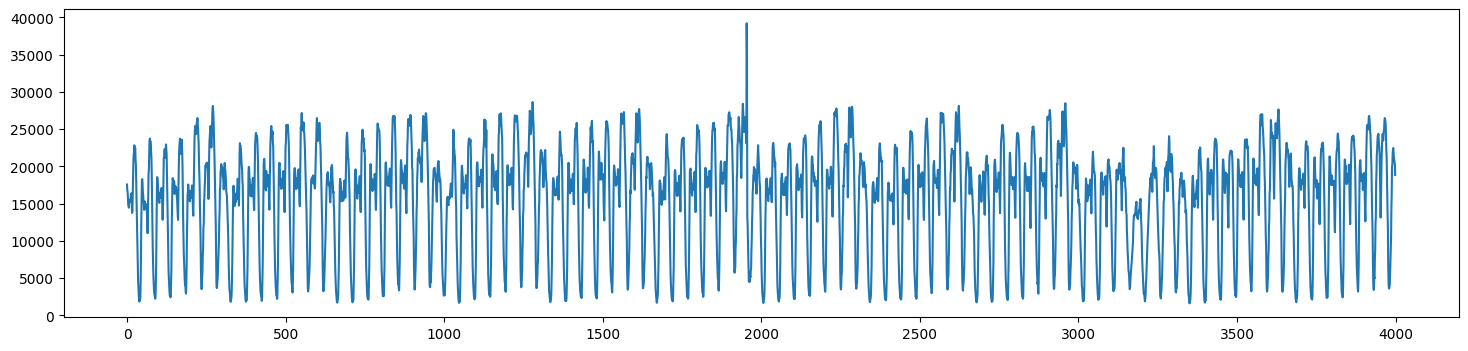

In [11]:
nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64)
fig = plt.figure(figsize=(18, 4))
plt.plot(nyc_taxi)

In [12]:
from modules.saxpy.discord import find_discords_brute_force
from modules.saxpy.hotsax import find_discords_hotsax

taxi_size_sub = 50
taxi_result = {}
taxi_times = {}

# Полный перебор
print("Выполняется полный перебор...", flush=True)

start = time()
taxi_result['Brute Force'] = np.asarray(
    find_discords_brute_force(nyc_taxi, taxi_size_sub, 5)
).reshape(-1, 2)
taxi_times['Brute Force'] = time() - start

print(
    f"Полный перебор завершен: "
    f"{taxi_times['Brute Force']:.3f} секунд",
    flush=True
)

# HotSAX
print("Выполняется HotSAX...", flush=True)

start = time()
taxi_result['HotSAX'] = np.asarray(
    find_discords_hotsax(
        nyc_taxi,
        win_size=taxi_size_sub,
        num_discords=5
    )
).reshape(-1, 2)
taxi_times['HotSAX'] = time() - start

print(f"HotSAX завершен: {taxi_times['HotSAX']:.3f} секунд")

# Вывод результатов
for name, discords in taxi_result.items():
    print(f"\n{name}:")
    for idx, distance in discords:
        print(f"Индекс: {int(idx)}, расстояние: {distance:.5f}")

Выполняется полный перебор...
Полный перебор завершен: 3159.855 секунд
Выполняется HotSAX...
HotSAX завершен: 10.926 секунд

Brute Force:
Индекс: 1910, расстояние: 3.52682
Индекс: 3120, расстояние: 3.40233
Индекс: 3183, расстояние: 2.64204
Индекс: 3237, расстояние: 2.22923
Индекс: 963, расстояние: 1.61153

HotSAX:
Индекс: 1910, расстояние: 3.52682
Индекс: 3120, расстояние: 3.40233
Индекс: 3183, расстояние: 2.64204
Индекс: 3237, расстояние: 2.22923
Индекс: 963, расстояние: 1.61153


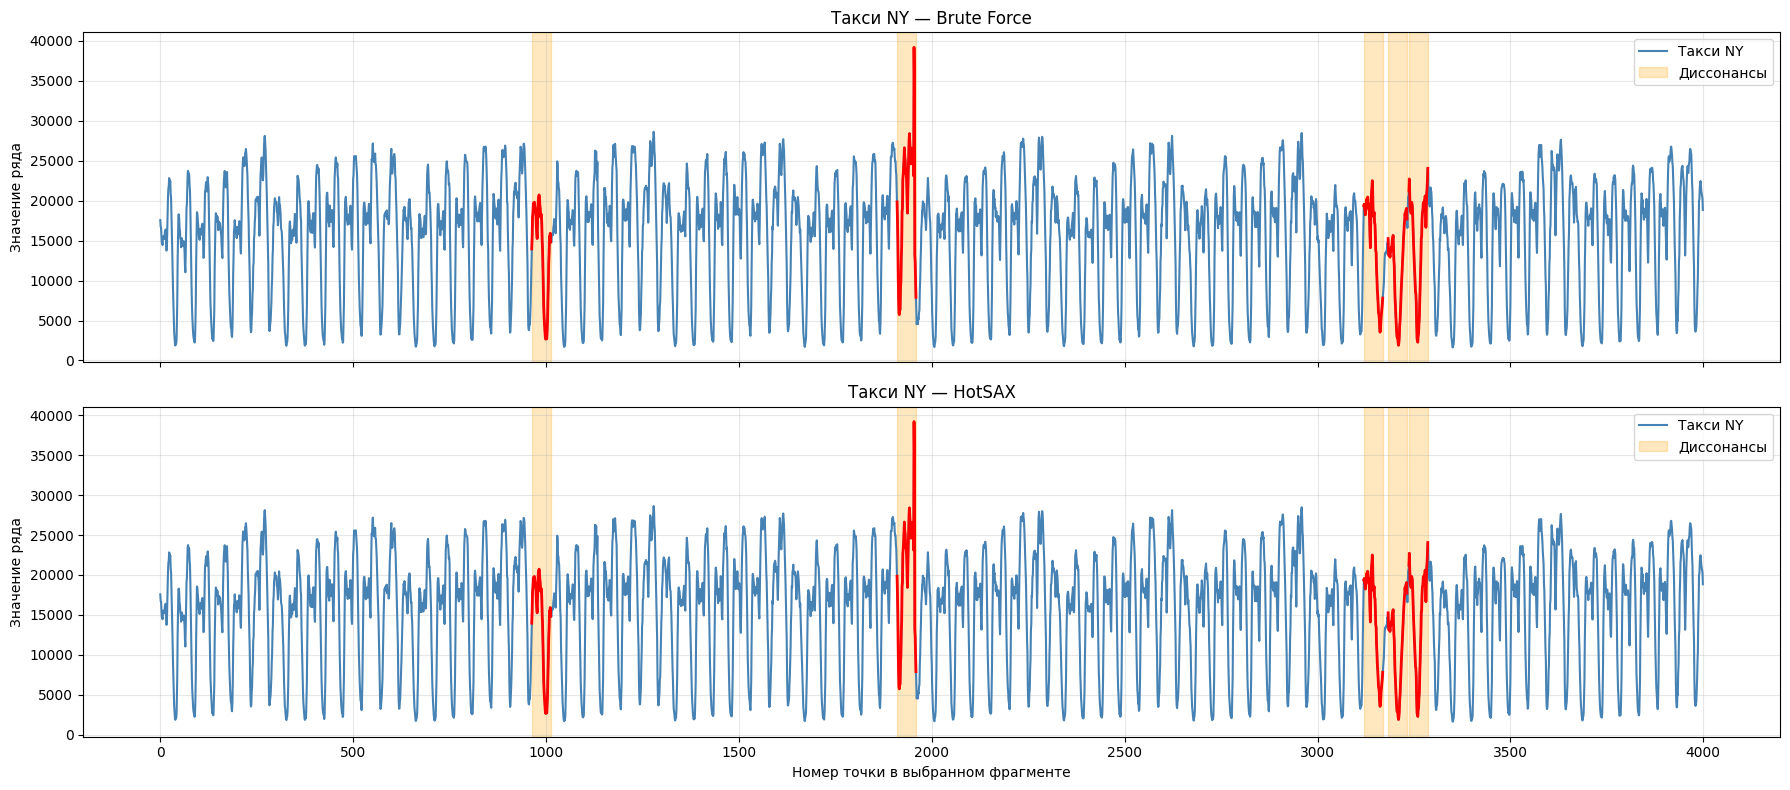

In [13]:
fig, axes = plt.subplots(
    2, 1, figsize=(18, 8), sharex=True, sharey=True
)

for ax, name in zip(axes, ['Brute Force', 'HotSAX']):
    ax.plot(nyc_taxi, color='steelblue', label='Такси NY')

    for number, (idx, distance) in enumerate(taxi_result[name]):
        idx = int(idx)
        stop = idx + taxi_size_sub

        ax.axvspan(
            idx, stop,
            color='orange',
            alpha=0.25,
            label='Диссонансы' if number == 0 else None
        )

        ax.plot(
            np.arange(idx, stop),
            nyc_taxi[idx:stop],
            color='red',
            linewidth=2
        )

    ax.set_title(f'Такси NY — {name}')
    ax.set_ylabel('Значение ряда')
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Номер точки в выбранном фрагменте')
plt.tight_layout()
plt.show()

## В первой части оба алгоритма нашли одинаковые диссонансы, но HotSAX справился намного быстрее. Значит, он дает такой же результат, как полный перебор, но лучше подходит для обработки больших временных рядов.

#### **3.2 Поиск диссонансов с помощью алгоритма DRAG**

In [14]:
!pip install stumpy==1.11.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.2/136.2 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: stumpy
    Found existing installation: stumpy 1.14.1
    Uninstalling stumpy-1.14.1:
      Successfully uninstalled stumpy-1.14.1


In [15]:
import stumpy
from stumpy import core, config
from stumpy.scrump import _prescrump


/usr/local/lib/python3.13/dist-packages/stumpy/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Как мы помним из лекций:

**Диапазонный диссонанс** – подпоследовательность ряда, расстояние от которой до ее ближайшего соседа не ниже заданного порога.

Основными параметрами при поисках диссонансов являются:
- $m$ - длина диссонанса
- $r$ - пороговое значение расстояния подпоследовательности ряда, до его ближайшего соседа


In [16]:
from modules.drag import find_candidates, DRAG


Для поиска диссонансов в данной части практической работы мы воспользуемся алгоритмом **DRAG (Discord Range Aware Gathering)**.
Для начала воспользуемся данным алгоритмом, чтобы найти диссонансы в наборе данных содержащем активность человека.

In [17]:
data = walk_run

Длину искомого диссонанса, как и для предыдущих алгоритмов, мы установим равно 50 точек.
Пороговое значение мы установим равным большим, чтобы узнать, как алгоритм отреагирует на большие значения данного параметра.

In [18]:
np.NINF = -np.inf
from modules.drag import find_candidates, DRAG

data = walk_run
m = 50
r = 10

idxs, _, _ = DRAG(data, m, r)

print(f'Количество найденных диссонансов: {len(idxs)}')

Количество найденных диссонансов: 0


Как вы можете видеть мы установили слишком большое пороговое значение, алгоритму не удалось выделить ни одного диссонанса. Попробуем уменьшить пороговое значение до 1, чтобы улучшить результат.

In [19]:
m = 50
r = 1
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 50


При такой комбинации параметров, улучшить ситуацию не получилось. Алгоритм выделил слишком большое количество диссонансов, часть которых является ложными диссонансами и не будут информативными для нас.

Произведите подобные эксперименты с набором данных такси NY. Постройте графики демонстрирующие найденные диссонансы. Пример Графика:
![second-graph](pics/fig_ex_2.png)

m = 50, r = 10: найдено диссонансов — 0
m = 50, r = 1: найдено диссонансов — 42


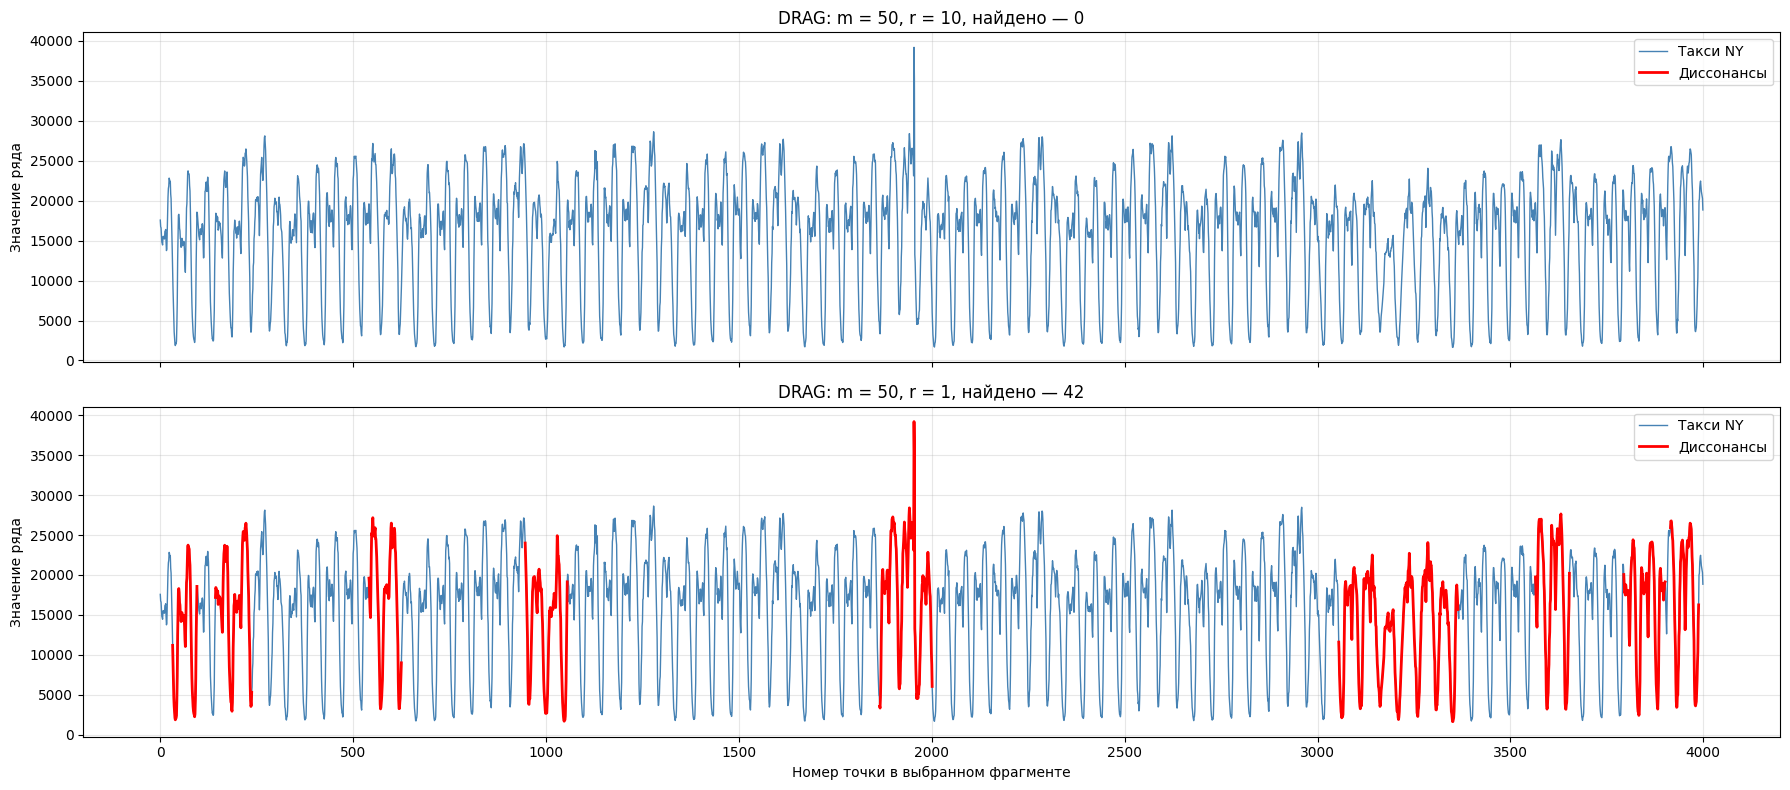

In [20]:
# INSERT YOUR CODE
m_taxi = 50
r_values = [10, 1]

fig, axes = plt.subplots(
    2, 1, figsize=(18, 8), sharex=True, sharey=True
)

for ax, r_value in zip(axes, r_values):
    taxi_idxs, _, _ = DRAG(nyc_taxi, m_taxi, r_value)
    taxi_idxs = np.asarray(taxi_idxs, dtype=int)

    print(
        f"m = {m_taxi}, r = {r_value}: "
        f"найдено диссонансов — {len(taxi_idxs)}"
    )

    ax.plot(
        nyc_taxi,
        color='steelblue',
        linewidth=1,
        label='Такси NY'
    )

    # Маска точек, входящих в найденные диссонансы
    mask = np.zeros(len(nyc_taxi), dtype=bool)

    for idx in taxi_idxs:
        mask[idx:idx + m_taxi] = True

    # Выделяем найденные участки красным
    highlighted = np.where(mask, nyc_taxi, np.nan)

    ax.plot(
        highlighted,
        color='red',
        linewidth=2,
        label='Диссонансы'
    )

    ax.set_title(
        f'DRAG: m = {m_taxi}, r = {r_value}, '
        f'найдено — {len(taxi_idxs)}'
    )
    ax.set_ylabel('Значение ряда')
    ax.legend()
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Номер точки в выбранном фрагменте')
plt.tight_layout()
plt.show()

Чтобы разобраться, почему так происходит и как работает данный алгоритм, ниже мы реализуем все этапы алгоритма DRAG.

Как мы помним из лекций алгоритм DRAG содержит два этапа:

1. Отбор - За одно сканирование ряда сформировать множество кандидатов в диссонансы.
2. Очистка - За одно сканирование ряда отбросить кандидатов, которые являются ложными диссонансами.

##### 3.2.1 Отбор кандидатов

Первым этапом обработки данных является отбор множества потенциальных кандидатов. Мы выбираем из всего множества подпоследовательностей ряда такие, для которых расстояние до правых ближайших соседей больше параметра $r$.

In [21]:
#выбирем более реальное значение для порога
r = 3

In [22]:
T, M_T, Σ_T = core.preprocess(data, m)
#формируем массив длинной равной длине  исходного ряда - m + 1,
#элемент массива является истинным,
#в том случае если подпоследовательность является потенциальным кандидатом
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
#находим индексы потенциальных кандидатов
cand_index = np.flatnonzero(is_cands)

In [23]:
print(f'{len(cand_index)} {len(cand_index)/len(data)*100} %')

113 11.3 %


Во время отбора кандидатов нам удалось выделить около 113 подпоследовательностей(около 11.3%), которые мы бы могли назвать потенциальными диссонансами.
Это большой процент, который не может нас устраивать как конечный результат.
Если посмотреть на рисунок ниже, мы увидим, что большая часть потенциальных диссонансов расположена в районе смены активности.
К сожалению пресутсвуют и ложные диссонансы, которые случайным образом попали в данный список.

Сформируйте график найденных диссонансов

In [24]:
# INSERT YOUR CODE

##### 3.2.2 Очистка кандидатов
Как уже упоминалось выше, 11.3% слишком большой процент диссонансов.
Для уменьшения числа потенциальных кандидатов произведем очистку от ложных диссонансов, путем сравнения расстояния до левых ближайших соседей потенциальных диссонансов с порогом $r$.


In [25]:
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
cands = np.flatnonzero(is_cands)

In [26]:
len(cands)/len(data)*100

2.9000000000000004

Сформируйте график найденных диссонансов

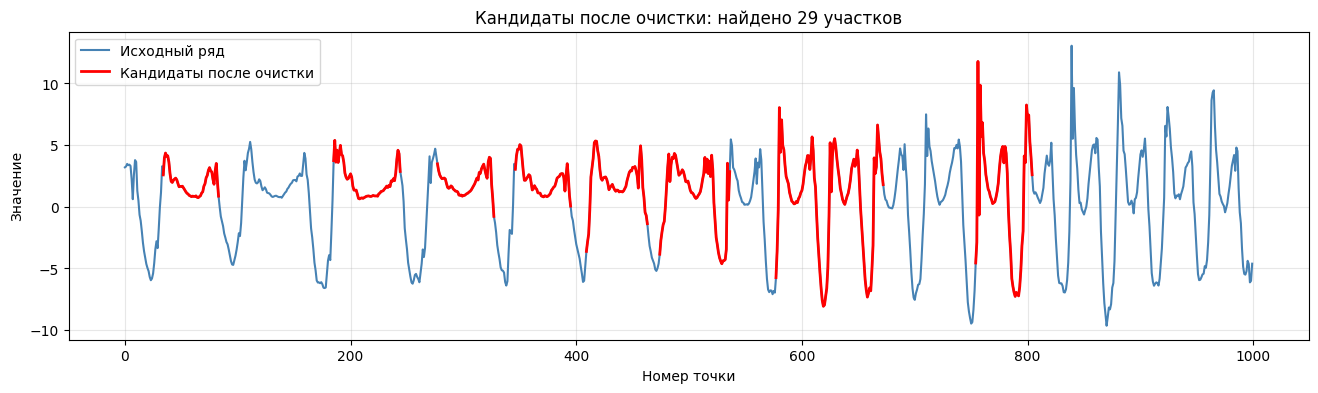

In [37]:
m = 50

mask = np.zeros(len(data), dtype=bool)

for idx in cands:
    mask[idx:idx + m] = True

plt.figure(figsize=(16, 4))

plt.plot(
    data,
    color='steelblue',
    label='Исходный ряд'
)

plt.plot(
    np.where(mask, data, np.nan),
    color='red',
    linewidth=2,
    label='Кандидаты после очистки'
)

plt.title(
    f'Кандидаты после очистки: найдено {len(cands)} участков'
)

plt.xlabel('Номер точки')
plt.ylabel('Значение')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Нам удалось сократить число диссонансов до 2.9%. Если проанализировать рисунок, то можно заметить, что большая их часть является тривиальными повторениями подпоследовательности в области смены активности. На следующем шаге избавимся от них.

In [38]:
from modules.drag import refine_candidates
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
len(discords_idx)/len(data)*100

0.8999999999999999

Сформируйте график найденных диссонансов

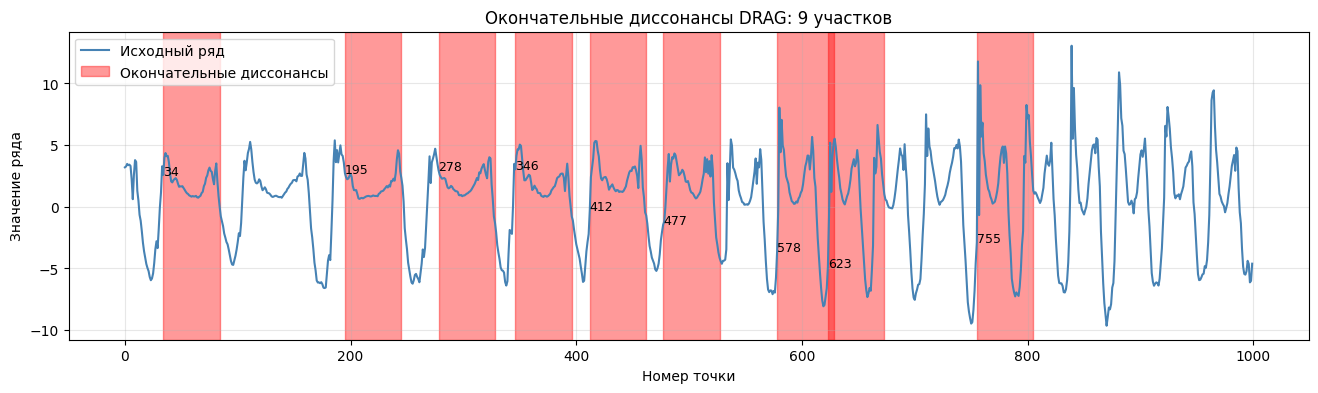

In [39]:
m = 50

discords_idx = np.asarray(discords_idx, dtype=int)

plt.figure(figsize=(16, 4))

plt.plot(
    data,
    color='steelblue',
    label='Исходный ряд'
)

for i, idx in enumerate(discords_idx):
    plt.axvspan(
        idx,
        idx + m,
        color='red',
        alpha=0.4,
        label='Окончательные диссонансы' if i == 0 else None
    )

    plt.text(
        idx,
        data[idx],
        str(idx),
        color='black',
        fontsize=9
    )

plt.title(
    f'Окончательные диссонансы DRAG: '
    f'{len(discords_idx)} участков'
)

plt.xlabel('Номер точки')
plt.ylabel('Значение ряда')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##### 3.2.3 Подбор параметров

Реализуйте перебор параметров $m$ и $r$. Подберете параметры таким образом, чтобы алгоритм обнаружил только те диссонансы, которые связаны со сменой активности. Сделайте вывод о том, как эти параметры влияют на качество работы модели.
Подберите оптимальные параметры алгоритма для набора данных такси NY.
Визуализируйте результаты для разных комбинаций. Сделайте выводы.


Количество диссонансов для walk/run:
[[64  0  0  0]
 [50  9  2  0]
 [40 22  1  0]
 [30 24  2  0]]

Количество диссонансов для NY Taxi:
[[68  4  0  0]
 [42  4  0  0]
 [67  8  1  0]
 [76  9  3  0]]


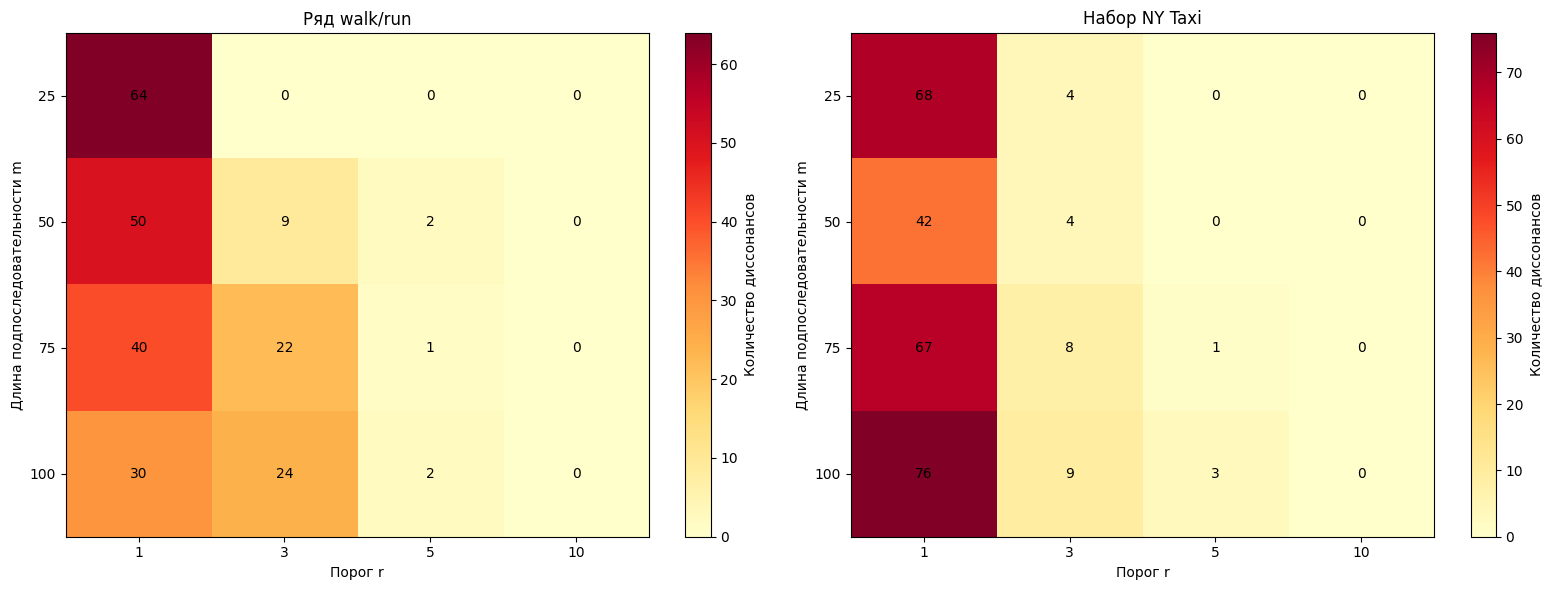

In [40]:
m_values = [25, 50, 75, 100]
r_values = [1, 3, 5, 10]


def count_discords(series, m, r):
    idxs, _, _ = DRAG(series, m, r)
    return len(idxs)


data_counts = np.zeros(
    (len(m_values), len(r_values)),
    dtype=int
)

taxi_counts = np.zeros(
    (len(m_values), len(r_values)),
    dtype=int
)


# Перебор параметров для walk/run
for i, m_value in enumerate(m_values):
    for j, r_value in enumerate(r_values):
        data_counts[i, j] = count_discords(
            data,
            m_value,
            r_value
        )


# Перебор параметров для NY Taxi
for i, m_value in enumerate(m_values):
    for j, r_value in enumerate(r_values):
        taxi_counts[i, j] = count_discords(
            nyc_taxi,
            m_value,
            r_value
        )


print('Количество диссонансов для walk/run:')
print(data_counts)

print('\nКоличество диссонансов для NY Taxi:')
print(taxi_counts)


# Визуализация результатов
fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, 6)
)


for ax, counts, title_text in zip(
    axes,
    [data_counts, taxi_counts],
    ['Ряд walk/run', 'Набор NY Taxi']
):
    image = ax.imshow(
        counts,
        cmap='YlOrRd',
        aspect='auto'
    )

    ax.set_title(title_text)
    ax.set_xlabel('Порог r')
    ax.set_ylabel('Длина подпоследовательности m')

    ax.set_xticks(range(len(r_values)))
    ax.set_xticklabels(r_values)

    ax.set_yticks(range(len(m_values)))
    ax.set_yticklabels(m_values)

    for i in range(len(m_values)):
        for j in range(len(r_values)):
            ax.text(
                j,
                i,
                counts[i, j],
                ha='center',
                va='center',
                color='black'
            )

    fig.colorbar(image, ax=ax, label='Количество диссонансов')


plt.tight_layout()
plt.show()

## Перебор показал, что при маленьком пороге r = 1 алгоритм находит слишком много диссонансов, включая ложные. При увеличении r их количество уменьшается, а при r = 10 некоторые аномалии уже не обнаруживаются. Оптимальным оказался вариант m = 75, r = 5, для ряда walk/run и NY Taxi находится небольшое количество наиболее выраженных диссонансов. Значит, увеличение порога снижает количество ложных срабатываний, а длина окна m влияет на масштаб анализируемого участка.

#### **3.3 Поиск диссонансов с помощью алгоритма Merlin**

Как мы уже выяснили подбирать параметры для DRAG простым перебором не очень удобно. Для оптимизации данного процесса в статье [1] был предложен алгоритм Merlin для оптимального поиска подходящего порогового значения.

Условно мы можем разделить поиск диссонансов на три шага:

1. Поиск диссонансов минимальной длинны $minL$. На данном шаге $r = 2\sqrt{minL}$.
2. Поиск диссонансов следующих четырех длин. На данном шаге $r = 0.99 \cdot nndist_{m-1}$. Где $nndist_{m-1}$ - расстояние до ближайшего соседа предыдущего найденного диссонанса.
3. Поиск диссонансов всех
оставшихся дли. $r = \mu - 2 \sigma$. Средние значение и стандартное отклонение вычисляются из расстояний 5 предыдущих диссонансов. н

[1] Nakamura T., Imamura M., Mercer R., Keogh E.J. MERLIN: parameter-free discovery of arbitrary length anomalies in massive time series archives. 20th IEEE Int. Conf. on Data Mining, ICDM 2020, Sorrento, Italy, November 17-20, 2020. pp. 1190-1195. IEEE (2020). https://doi.org/10.1109/ICDM50108.2020.00147

##### 3.3.1 Поиск диссонансов минимальной длинны

Вспомнил последовательность действий первого шага алгоритма:
![merlin-part-first](pics/first_part.png)

В данной работе мы внесем небольшое изменение, мы будем считать, что подпоследовательность может быть диссонансом только в том случае, если больше 75% точек, не входят в состав других диссонансов.

In [31]:
T = walk_run
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса,
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10


In [32]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [33]:
maxL

55

In [34]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 2


На первом шаге нам удалось выделить 2 диссонанса из 10 требуемых.
Реализуйте, оставшиеся шаги алгоритма, чтобы найти оставшиеся диссонансы.

![merlin-part-first](pics/second_part.png)


In [35]:
# INSERT YOUR CODE

Найдите диссонансы набора такси NY. Визуализируйте найденные диссонансы для обоих наборов данных, сравните с результатами остальных методов.


In [36]:
# INSERT YOUR CODE